# IHS - Social Cohesion and Polarization - Project

My (mini-)project will be about the following question:

### Subjective Financial Strain and Redistribution Preferences in Austria

**At similar household income levels, is feeling more financially strained linked to stronger support for redistribution?**

I chose this question because it fits quite well with the topics of the IHS - Social Cohesion and Polarization group.

After reading through the ``Ergebnis-Bericht der Welle 11 des European Social Survey (ESS 2025)``, I thought this would be a natural small follow-up. The report already looks at redistribution preferences, household income and how people assess their own financial situation, but mostly from a descriptive perspective.

So I want to take this one step further and look at whether subjective financial strain is still associated with redistribution preferences once household income position is taken into account.

For that I will be using ESS Round 11 data as well as the corresponding codebook.

## 1. First steps - Loading Packages and Data

In [1]:
###### Packages #####

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

Now off to loading the dataset:

I am using the [ESS Round 11 Integrated File, Edition 4.2](https://ess.sikt.no/en/datafile/242aaa39-3bbb-40f5-98bf-bfb1ce53d8ef) from the ESS, which I downloaded as a csv. One can easily load the data by using pandas and the ``.read_csv()`` - method.

In [3]:
# Loading the raw data
raw_data = pd.read_csv("C:/Users/aaron/PythonProjects/IHS_Project/Data/ESS11e04_2.csv", low_memory=False)

# Getting a quick overview of the data. 
# low_memory=False read the full CSV at once to avoid mixed-type warnings.
# Just typing the name of the dataframe will give us a quick overview of the data, 
# including the number of rows and columns, as well as the first and last five rows of the data. 

raw_data

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04_2,11,4.2,02.07.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaN,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1,2.0,0.000579,107,317
1,ESS11e04_2,11,4.2,02.07.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaN,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1,1.0,0.001124,69,128
2,ESS11e04_2,11,4.2,02.07.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
3,ESS11e04_2,11,4.2,02.07.2026,50106,AT,0.556062,0.176228,0.330915,0.058316,...,NaN,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1,1.0,0.001233,101,295
4,ESS11e04_2,11,4.2,02.07.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaN,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1,2.0,0.000949,115,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50111,ESS11e04_2,11,4.2,02.07.2026,273742,UA,1.194824,1.194824,1.310703,1.566060,...,NaN,2024-05-20 21:19:06,2024-05-20 21:19:15,2024-05-20 21:22:56,37.0,1,1.0,0.000184,1492,25303
50112,ESS11e04_2,11,4.2,02.07.2026,273743,UA,0.436757,0.436757,1.310703,0.572459,...,NaN,2024-05-11 12:09:29,2024-05-11 12:09:36,2024-05-11 12:21:45,33.0,1,2.0,0.000505,1516,25311
50113,ESS11e04_2,11,4.2,02.07.2026,273747,UA,1.067750,1.067750,1.310703,1.399503,...,NaN,2024-05-23 15:50:19,2024-05-23 15:50:27,2024-05-23 15:54:37,29.0,1,1.0,0.000206,1495,25334
50114,ESS11e04_2,11,4.2,02.07.2026,273838,UA,0.597412,0.597412,1.310703,0.783030,...,NaN,2024-05-08 13:32:18,2024-05-08 13:32:23,2024-05-08 13:39:30,53.0,1,1.0,0.000369,1492,25303


A quick check of how the country code is stored, to see whether there is any hidden whitespace:

In [ ]:
repr(raw_data.iloc[0,5])

"'AT'"

Okay, so we can see that this is a pretty large dataset: 50,116 rows and 691 columns.

The data itself looks pretty good, and is already pretty much fit for work - the ESS data is cross-sectional and already arranged with one respondent per row and the variables in separate columns. So no need for reshaping or transform the data first, we can move directly to identifying observations and variables that are relevant.

The 50,116 rows are not Austrian respondents only, but respondents from all countries included in ESS Round 11. According to the Austrian ESS report, the Austrian sample itself contains 2,354 respondents, meaning we will have to kick most of the rows (Countries other than Austria) and keep Austria only.

The 691 columns represent all the different variables included in the dataset, far more than we need for this project.

Which is also our next step, figuring out and motivating which variables will be helpful for our project. For this the codebook will be very helpful, and serve as a source for which variables to use.  

## 2. Choosing the relevant variables for Austria

Now to build a dataset with only relevant data, we have to see which variables are useful for our purpose and choose them as a new dataset.
Looking through the codebook, the following variables seem helpful:

Outcome -Variable:
- `gincdif`: support for reducing differences in income levels.

Input-Variables:
- `hincfel`: how respondents feel about their current household income - which captures subjective financial strain.
- `hinctnta`: household net income position (in deciles) - so we can compare subjective financial strain at similar income levels.
- `agea`: age.
- `gndr`: gender.
- `eduyrs`: years of education.
- `uemp3m`: whether someone has ever been unemployed and looking for work (for more than three months).
- `hhmmb`: number of people living in the household.
- `lrscale`: left-right political self-placement - might be useful later as an additional check.
- `anweight`: the ESS analysis weight.
- `idno`: respondent ID.
- `cntry`: country -  we want Austria only.


Next step is to create a dataset with exactly these columns, effectively reducing the data to work with: 

In [ ]:
# create a list of said variables
variables = ["idno","cntry","gincdif","hincfel","hinctnta","agea","gndr","eduyrs","uemp3m","hhmmb","lrscale","anweight"]
variables

['idno',
 'cntry',
 'gincdif',
 'hincfel',
 'hinctnta',
 'agea',
 'gndr',
 'eduyrs',
 'uemp3m',
 'hhmmb',
 'lrscale',
 'anweight']

Next is to filter for the selected data. Using the .loc method is the cleanest version here, since one pretty much filters like [row-argument, column-argument]:

In [ ]:
# Filter data for Austria; .loc is used to select rows and columns by label. 
# In this case, we are selecting all rows where the "cntry" column is equal to "AT" (Austria) and only the columns specified in the variables list. 
# The .copy() method is used to create a copy of the filtered data, which is stored in a new dataframe called df.
df = raw_data.loc[raw_data["cntry"] == "AT", variables].copy()
df 

,idno,cntry,gincdif,hincfel,hinctnta,agea,gndr,eduyrs,uemp3m,hhmmb,lrscale,anweight
0,50014,AT,2,1,6,65,1,12,2,2,5,0.130013
1,50030,AT,1,2,1,21,2,14,2,1,0,0.107598
2,50057,AT,1,1,5,53,2,16,2,3,3,1.323666
3,50106,AT,1,2,2,78,2,14,2,1,5,0.058316
4,50145,AT,2,2,77,64,1,12,2,2,2,0.351080
...,...,...,...,...,...,...,...,...,...,...,...,...
2349,86428,AT,1,2,6,88,2,12,2,2,4,0.260184
2350,86437,AT,4,1,6,67,1,12,2,1,5,0.053822
2351,86454,AT,1,3,77,33,2,9,1,3,88,0.337693
2352,86475,AT,2,2,77,50,1,12,2,3,4,0.162121


Okay, looks great! This is exactly the amount of observations we should have according to the Ergebnis–Bericht der Welle 11 - 2354 rows = 2354 individuals.

Now let's move on to check the data for any inconsistencies.

## 3. Checking for inconsistencies

With our dataset at hand, we should now check the data before we start to work with it. A good idea to check would be:

- datatypes
- missingness (NaN)
- consistant values, i.e. according to the codebook - ``gincdif`` can have values from 1 to 5 (answer) and 7 to 9 (Refusal, Don't Know, No Answer)

In [ ]:
df.dtypes

idno          int64
cntry        object
gincdif       int64
hincfel       int64
hinctnta      int64
agea          int64
gndr          int64
eduyrs        int64
uemp3m        int64
hhmmb         int64
lrscale       int64
anweight    float64
dtype: object

Looks fine, let's check for missing data:

In [ ]:
df.isna().sum()

idno        0
cntry       0
gincdif     0
hincfel     0
hinctnta    0
agea        0
gndr        0
eduyrs      0
uemp3m      0
hhmmb       0
lrscale     0
anweight    0
dtype: int64

Now, this is on first sight very good, no missing data usually means less trouble.
But if we take a look at the codebook, we can see why that is:

According to the codebook, missing data is assigned to a code-number.

For example gincdif has values from 1-5 (Agree strongly = 1, Disagree strongly = 5) and 7-9, which are: refusal to answer = 7, don't know = 8, No answer = 9;

Meaning that the answers 1-5 are actual answers to the question and 7-9 would be different forms of missingness. The different forms of missingness are important, because it might be non-random for some specific groups; Let's say High Household Income -> More likely to refuse to answer (or don't know) for questions regarding redistribution. This might/would be a problem we have to check as well.

But first we should check values of the variables, and see the range they are usually assigned to. For that, the value_counts-method is most natural. 

In [ ]:
# We check the unique values of the "gincdif" variable to see if there are any missing or invalid values.
# We sort the unique values by index to get a better overview of the data.
df["gincdif"].value_counts().sort_index()


gincdif
1     887
2    1090
3     179
4     104
5      41
7       5
8      48
Name: count, dtype: int64

Looks plausible, 5 times a ``refusal to answer``, 48 times `don't know`  and 0 time ``no answer``, so no 9's.

Now we should check every variable for their (plausible) range of values. For that we first should use the range given by the codebook, since they are not uniform.

To make this easier, we can first summarize the valid values and the values marked as missing in the ESS codebook:

| Variable | Valid values | Missing values |
|---|---|---|
| `gincdif` | 1–5 | 7 = Refusal, 8 = Don't know, 9 = No answer |
| `hincfel` | 1–4 | 7 = Refusal, 8 = Don't know, 9 = No answer |
| `hinctnta` | 1–10 | 77 = Refusal, 88 = Don't know, 99 = No answer |
| `agea` | calculated age | 999 = Not available |
| `gndr` | 1 = Male, 2 = Female | 9 = No answer |
| `eduyrs` | reported years of education | 77 = Refusal, 88 = Don't know, 99 = No answer |
| `uemp3m` | 1 = Yes, 2 = No | 7 = Refusal, 8 = Don't know, 9 = No answer |
| `hhmmb` | reported number of household members | 77 = Refusal, 88 = Don't know, 99 = No answer |
| `lrscale` | 0–10 | 77 = Refusal, 88 = Don't know, 99 = No answer |

`idno`, `cntry` and `anweight` do not use the same kind of special missing-value codes in the codebook and therefore do not need the same recoding step.

In [ ]:
count_vars = ["gincdif","hincfel","gndr","uemp3m","hhmmb","lrscale","hinctnta"]

value_counts_table = (
    df[count_vars]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .astype(int)
    .sort_index()
    .rename_axis("Value")
    .replace(0, "-")
)

value_counts_table

,gincdif,hincfel,gndr,uemp3m,hhmmb,lrscale,hinctnta
Value,,,,,,,
0,-,-,-,-,7,40,-
1,887,755,993,525,932,47,94
2,1090,1247,1361,1824,911,109,269
3,179,283,-,-,273,190,292
4,104,54,-,-,173,285,197
5,41,-,-,-,44,931,177
6,-,-,-,-,9,248,240
7,5,8,-,4,5,147,221
8,48,7,-,1,-,95,201


In [ ]:
df["agea"].isin([999]).sum(), df["eduyrs"].isin([77, 88, 99]).sum(), df["eduyrs"].isin([99]).sum()


(np.int64(0), np.int64(46), np.int64(0))

Okay, so a few interesting things to note:

- Aside from gndr, ``hhmmb`` & ``agea``; every entry has missingness-entries. 
- There is no 9 for ``gincdif`` - ``uemp3m`` -> So no ``no answer``.
- For ``hhmmb``,``lrscale``, ``hinctnta`` & ``eduyrs`` there is also no 99 -> no `no answer`
- For age, there is also always a given answer, so no missing values - no ``999``

All of this seems plausible/unproblematic, but there is another point to be observed:

- There are two variables which have a 0 value; lrscale (left-right politically) - which goes from 0-10; hhmmb (reported number of household members including yourself) - which by logic should be > 0. 


We should definitely give these cases a closer look and check the specific cases where this is happening for `hhmmb`:


In [ ]:
# We check the unique values in the 'hhmmb' column.
df.loc[df["hhmmb"] == 0, ["idno","agea","gndr","hincfel","hinctnta","hhmmb"]]

,idno,agea,gndr,hincfel,hinctnta,hhmmb
230,53820,21,2,1,4,0
317,55271,46,2,1,7,0
896,63876,36,2,2,88,0
1314,70725,90,2,2,2,0
1475,73136,35,2,1,7,0
1619,75331,30,1,2,1,0
1996,81135,52,2,1,7,0


Okay, this looks actually pretty ordinary. At least I can't tell from these numbers why there is a 0.
Thinking about it, there might be several reasons why:

1. `hhmmb` is number of people living in your household, **including** yourself. Maybe the people misread/misunderstood and excluded themselves?
2. Maybe the people view themselves currently homeless / difficult housing-situation? But this would be rather unlikely, since the ESS specifically questions people over 15 and who have a "private dwelling". 
3. Mistake by the ESS

2 & 3 are hard to investigate; 1 actually might be possible. If people misunderstood the question in so far, that they thought the question was how many people are living in your household **excluding** yourself, we might use other variables that indicate, that these people live actually alone in their household.

The Codebook has the following variables:
1. `gndr2` = Gender of second person in household;                             For : 6 ->	Not applicable
2. `rshipa2` = Second person in household: relationship to respondent;          For : 66 ->   Not applicable
3. `yrbrn2` = Year of birth of second person in household; For : 6666 -> Not applicable


So if these observations for these 3 variables and their corresponding values, are indeed  ``not applicable``, it might be plausible to infer that the people who were asked were probably mistaken. 


In [ ]:
raw_data.loc[(raw_data["cntry"] == "AT") & (raw_data["hhmmb"] == 0), ["idno", "hhmmb", "gndr2", "yrbrn2","rshipa2"]]

,idno,hhmmb,gndr2,yrbrn2,rshipa2
230,53820,0,6,6666,66
317,55271,0,6,6666,66
896,63876,0,6,6666,66
1314,70725,0,6,6666,66
1475,73136,0,6,6666,66
1619,75331,0,6,6666,66
1996,81135,0,6,6666,66


Indeed, we can see that these people do seem to live alone. It seems plausible, that the respondents may have misunderstood the `hhmmb` question and reported the number of other people living in the household instead of including themselves. But this is just a plausible explanation, since there might also be another reason for the recorded zeros, some I have already given (Homeless or mistake)

Usually we should be doing a more thorough consistency check and look for the same pattern across the full ESS dataset and compare whether `hhmmb = 0` occurs in other countries or interviews as well, which might help to see whether the issue occurs systematically. But since this is just a small project, I will not be doing this here.

Now, given that the household roster is consistant with these respondents living alone, I will treat the seven observations as one-person households and recode `hhmmb = 0` to `hhmmb = 1` in the cleaning step. The other possibility, would be to exclude these observations or insert a NaN.

Okay, aside from this inconsistency, the remaining issue is the set of special values that the ESS codebook explicitly defines as missing. Before starting the actual analysis, these values therefore have to be converted into proper `NaN` values, which we will do in the next chapter:

## 4. Cleaning and preparing the data

### 4.1 Data-cleaning


First we should now replace the 0's in ``hhmmb`` with 1's, as explained in the last part:

In [ ]:
# We replace the 0 values in the 'hhmmb' column with 1, as it is not possible to have a household size of 0.
df["hhmmb"] = df["hhmmb"].replace(0, 1)

# small check:

df["hhmmb"].value_counts().sort_index()

hhmmb
1    939
2    911
3    273
4    173
5     44
6      9
7      5
Name: count, dtype: int64

Looks good! Now let's move on to the missingness-values. For extensive analysis it would definitely be a good idea to check randomness for these missingness-values (i.e. non-answers), for different variables that might seem plausible to be more likely to give a non-answer. But for this data-cleaning and short analysis project, this would be more extensive and can be left for future work.

Meaning the next step is to just unify the missingness values into NaN's to make analysis workable. There are multiple ways to make this work, by loop for example, but the best way is probably to just use a dictionary and then a small for loop:

In [ ]:
missing_codes = {
    "gincdif": [7,8,9],
    "hincfel": [7,8,9],
    "gndr": [9],
    "uemp3m": [7,8,9],
    "hinctnta": [77,88,99],
    "eduyrs": [77,88,99],
    "hhmmb": [77,88,99],
    "lrscale": [77,88,99],
    "agea": [999]
}

for vars, codes in missing_codes.items():
    df[vars] = df[vars].replace(codes, np.nan)

In [ ]:
missing_summary = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_summary

,Missing count,Missing %
idno,0,0.00
cntry,0,0.00
gincdif,53,2.25
hincfel,15,0.64
hinctnta,502,21.33
agea,0,0.00
gndr,0,0.00
eduyrs,46,1.95
uemp3m,5,0.21
hhmmb,0,0.00


Okay, looks good, we had 377 = 77 and 125 =88 for `hinctnta` before, now that we have merged them both as NaN's, we have 502 NaN's -> 377+125 =502, which is consistant.

Let's check the variables quickly again as a check:

In [ ]:
count_vars = ["gincdif","hincfel","gndr","uemp3m","hhmmb","lrscale","hinctnta"]

value_counts_table = (
    df[count_vars]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .astype(int)
    .sort_index()
    .rename_axis("Value")
    .replace(0, "-")
)

value_counts_table

,gincdif,hincfel,gndr,uemp3m,hhmmb,lrscale,hinctnta
Value,,,,,,,
0.0,-,-,-,-,-,40,-
1.0,887,755,993,525,939,47,94
2.0,1090,1247,1361,1824,911,109,269
3.0,179,283,-,-,273,190,292
4.0,104,54,-,-,173,285,197
5.0,41,-,-,-,44,931,177
6.0,-,-,-,-,9,248,240
7.0,-,-,-,-,5,147,221
8.0,-,-,-,-,-,95,201


In [ ]:
df["agea"].isin([999]).sum(), df["eduyrs"].isin([77, 88, 99]).sum(), df["eduyrs"].isin([99]).sum()

(np.int64(0), np.int64(0), np.int64(0))

Looks good! With that we can move to the final preparation of the data. We have to transform some of the data to make them more workable.


### 4.2 Transforming the variables

Most of the variables are coded on a scale of 1-5 or 1-10 and so on, we should first make sure that their direction is intuitive for what we want to measure.

For the outcome variable `gincdif`, the original scale goes from 1 = "Agree strongly" to 5 = "Disagree strongly" with the statement that the government should reduce differences in income levels, so the lower the score, the higher the support for redistribution.

For the later analysis it would be more intuitive if higher values instead represent stronger support, which is why I will reverse the scale and create a new variable called `redist_support`, going from 1 = low support to 5 = strong support for redistribution.

The other two main variables already have a useful direction for the analysis. For ``hincfel``, higher values indicate greater financial strain, while for ``hinctnta``, higher values indicate a higher household income decile. So both variables can remain the way they are as of now.

The rest of the control variables can also stay in their original coding for now, since variables such as age, years of education and household size are already directly interpretable, while categorical variables such as gender and unemployment status can later be treated as categories in further analysis.

Okay, then let's transform `gincdif`:

In [ ]:
df["redist_support"] = 6 - df["gincdif"] 

df

,idno,cntry,gincdif,hincfel,hinctnta,agea,gndr,eduyrs,uemp3m,hhmmb,lrscale,anweight,redist_support
0,50014,AT,2.0,1.0,6.0,65,1,12.0,2.0,2,5.0,0.130013,4.0
1,50030,AT,1.0,2.0,1.0,21,2,14.0,2.0,1,0.0,0.107598,5.0
2,50057,AT,1.0,1.0,5.0,53,2,16.0,2.0,3,3.0,1.323666,5.0
3,50106,AT,1.0,2.0,2.0,78,2,14.0,2.0,1,5.0,0.058316,5.0
4,50145,AT,2.0,2.0,NaN,64,1,12.0,2.0,2,2.0,0.351080,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349,86428,AT,1.0,2.0,6.0,88,2,12.0,2.0,2,4.0,0.260184,5.0
2350,86437,AT,4.0,1.0,6.0,67,1,12.0,2.0,1,5.0,0.053822,2.0
2351,86454,AT,1.0,3.0,NaN,33,2,9.0,1.0,3,NaN,0.337693,5.0
2352,86475,AT,2.0,2.0,NaN,50,1,12.0,2.0,3,4.0,0.162121,4.0


Looks good! With that we are pretty much done and can move on to the analysis of the data.

## 5. Descriptive Analysis

With our current dataframe, we should (like always) start with descriptive analysis. This is especially useful, since we can compare some of our descriptive results with those reported in the ``Ergebnis-Bericht der Welle 11 des European Social Survey (ESS 2025)``.

We have to keep in mind though, that since the ESS provides an analysis weight (`anweight`), the descriptive results below will use this weight when appropriate. I will first use the unweighted summary mainly as a comparison, while for the actual descriptive analysis I will use the weighted values.

Let's start with a summary:

In [ ]:
df[["redist_support", "hincfel", "hinctnta", "agea", "gndr", "eduyrs", "uemp3m", "hhmmb", "lrscale", "anweight"]].describe().round(2)

,redist_support,hincfel,hinctnta,agea,gndr,eduyrs,uemp3m,hhmmb,lrscale,anweight
count,2301.00,2339.00,1852.00,2354.00,2354.00,2308.00,2349.00,2354.00,2131.00,2354.00
mean,4.16,1.84,5.01,55.64,1.58,12.65,1.78,1.95,4.82,0.33
std,0.88,0.72,2.48,18.32,0.49,3.42,0.42,1.04,1.70,0.32
min,1.00,1.00,1.00,15.00,1.00,0.00,1.00,1.00,0.00,0.03
25%,4.00,1.00,3.00,42.00,1.00,11.00,2.00,1.00,4.00,0.12
50%,4.00,2.00,5.00,57.00,2.00,12.00,2.00,2.00,5.00,0.22
75%,5.00,2.00,7.00,70.00,2.00,14.00,2.00,2.00,5.00,0.40
max,5.00,4.00,10.00,90.00,2.00,47.00,2.00,7.00,10.00,1.32


Okay, so overall the summary does not show anything particularly special. The central variables are within their expected ranges, and mean and median are relatively close for the main variables of interest, without crazy standard deviations. Maybe the max of 47 for `eduyrs` might be a bit eyecatching, but certainly not impossible.

As a next step it might be interesting to see what kind of distributions we have for some of the central variables: `redist_support`, `hincfel`, `hinctnta`.

For this, we should also keep the ESS analysis weight (`anweight`) in mind, as the Austrian sample does not perfectly represent the Austrian population. `anweight` adjusts for these differences in selection probabilities and differences between the sample and the target population.


To get a grip on the differences, we should first still look at the unweighted distribution.
Let's start with `redist_support`:

In [ ]:
(df["redist_support"].value_counts(normalize=True).sort_index() * 100).round(2), (df["redist_support"].value_counts(normalize=True).sort_index() * 100).sum()

(redist_support
 1.0     1.78
 2.0     4.52
 3.0     7.78
 4.0    47.37
 5.0    38.55
 Name: proportion, dtype: float64,
 np.float64(100.0))

Okay, these numbers are almost identical to the distribution reported in the 2025 ESS report:

| `redist_support` | ESS Report 2025 |
|---|---:|
| 1 | 1.8% |
| 2 | 4.5% |
| 3 | 7.8% |
| 4 | 47.4% |
| 5 | 38.6% |

Let's compare that with the weighted version:

In [ ]:
# Sum the analysis weights for each valid category of redist_support.
# Observations with missing redist_support are automatically excluded by groupby().
redist_weighted_sum = df.groupby("redist_support")["anweight"].sum()

# Divide the weight of each category by the total analysis weight of the sample.
redist_weighted_sum / df["anweight"].sum() * 100

redist_support
1.0     1.594046
2.0     4.569036
3.0     7.815321
4.0    48.854805
5.0    34.464275
Name: anweight, dtype: float64

Okay, we can already see that weighting changes the distribution somewhat compared to the unweighted version. Especially the shares for `redist_support = 4` and `redist_support = 5` change a bit.


In [ ]:
(redist_weighted_sum / df["anweight"].sum() * 100).sum()

np.float64(97.29748313191092)

Huh! Well, that only adds up to around 97.3%

So, now looking back at the calculation, `groupby("redist_support")` automatically excludes the 53 observations with missing `redist_support`. However, `df["anweight"].sum()` still uses the weights of all respondents, including those 53 observations.

This then means that the numerator only refers to respondents with a valid `redist_support` value, while the denominator still refers to the full sample.  Using the sum of `redist_weighted_sum` as the denominator should fix that.

In [ ]:
# Divide each category's weight by the total weight of all valid redist_support observations.
redist_weighted = (redist_weighted_sum / redist_weighted_sum.sum() * 100).round(2)

redist_weighted, redist_weighted.sum()

(redist_support
 1.0     1.64
 2.0     4.70
 3.0     8.03
 4.0    50.21
 5.0    35.42
 Name: anweight, dtype: float64,
 np.float64(100.0))

Looks like it worked. The weighted distribution is somewhat different, especially between the two highest support categories. The share for `redist_support = 4` increases from 47.37% to 50.21%, while the share for `redist_support = 5` decreases from 38.55% to 35.42%. 

Next step is the same for the other two variables - `hincfel` & `hinctnta`, which is a bit more straightforward:

`hincfel`

In [ ]:
(df["hincfel"].value_counts(normalize=True).sort_index() * 100).round(2), (df["hincfel"].value_counts(normalize=True).sort_index() * 100).sum()

(hincfel
 1.0    32.28
 2.0    53.31
 3.0    12.10
 4.0     2.31
 Name: proportion, dtype: float64,
 np.float64(100.0))

In [ ]:
hincfel_sum = df.groupby("hincfel")["anweight"].sum()
hincfel_weighted = (hincfel_sum / hincfel_sum.sum() * 100).round(2)

hincfel_weighted, hincfel_weighted.sum()

(hincfel
 1.0    36.95
 2.0    50.42
 3.0    10.15
 4.0     2.48
 Name: anweight, dtype: float64,
 np.float64(100.00000000000001))

For `hincfel`, the weighting also changes the distribution. Most respondents report either living comfortably or coping on their present income, only a relatively small share reports that their financial situation is difficult or very difficult.

`hinctnta`

In [ ]:
(df["hinctnta"].value_counts(normalize=True).sort_index() * 100).round(2), (df["hinctnta"].value_counts(normalize=True).sort_index() * 100).sum().round(2)

(hinctnta
 1.0      5.08
 2.0     14.52
 3.0     15.77
 4.0     10.64
 5.0      9.56
 6.0     12.96
 7.0     11.93
 8.0     10.85
 9.0      5.40
 10.0     3.29
 Name: proportion, dtype: float64,
 np.float64(100.0))

In [ ]:
hinctnta_sum = df.groupby("hinctnta")["anweight"].sum()
hinctnta_weighted = (hinctnta_sum / hinctnta_sum.sum() * 100).round(2)

hinctnta_weighted, hinctnta_weighted.sum()

(hinctnta
 1.0      3.92
 2.0     11.12
 3.0     12.37
 4.0      8.97
 5.0     10.31
 6.0     13.36
 7.0     12.28
 8.0     14.28
 9.0      7.01
 10.0     6.38
 Name: anweight, dtype: float64,
 np.float64(100.0))

The weighting for `hinctnta` changes the distribution more visibly than for the other two. The weighted sample places somewhat more weight on the middle and upper income deciles, the lowest and highest deciles remain less frequent.

Okay, the descriptive analysis shows that our numbers are very similar to the ones of the ESS 2025 Report, which is good! We can also see that the weights do indeed change the distributions somewhat.

Next off is the actual analysis!

## 6. Regression Analysis

Let's get straight into it with a first model where we look only at `redist_support` and `hincfel`.

To account for the ESS analysis weights (`anweight`), I use Weighted Least Squares (WLS). Since `hincfel` consists of four categories, I treat it as a categorical variable using `C(.)`, which creates dummy variables with the first category as the reference group.

Since our outcome is a short 1–5 scale and the variation may not be the same across all respondents, I use HC3 robust standard errors to allow for heteroskedasticity, while also using a somewhat more conservative correction for observations that may have a strong influence on the regression.

In [ ]:
model_1 = smf.wls(formula="redist_support ~ C(hincfel)", data=df, weights=df["anweight"]).fit(cov_type="HC3")

model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:         redist_support   R-squared:                       0.014
Model:                            WLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     5.456
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           0.000978
Time:                        14:29:35   Log-Likelihood:                -3341.7
No. Observations:                2286   AIC:                             6691.
Df Residuals:                    2282   BIC:                             6714.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.0125      0.043     92.617      0.000       3.928       4.097
C(hincfel)[T.2.0]     0.1600      0.053      3.008      0.003       0.056       0.264
C(hincfel)[T.3.0]     0.2633      0.091      2.906      0.004       0.086       0.441
C(hincfel)[T.4.0]     0.4218      0.159      2.647      0.008       0.110       0.734
==============================================================================
Omnibus:                      795.166   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3713.261
Skew:                          -1.604   Prob(JB):                         0.00
Kurtosis:                       8.356   Cond. No.                         7.67
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

So our first model shows a positive relationship between financial strain and support for redistribution. Compared with respondents who report living comfortably, all three groups experiencing greater financial strain show higher levels of redistribution support.

The estimated difference increases with financial strain, from about 0.16 points for respondents who are coping to about 0.42 points for those who find living on their present income very difficult, with all three differences being statistically significant at the 1% level. Also to note, this model does not explain a lot when it comes to R², which just sits at 0.014.

Now, this is a very simple model and does not yet account for actual household income, which will probably somewhat change the results, since financial strain and household income are likely related.

The next model adds `hinctnta`:

In [ ]:
model_2 = smf.wls(formula="redist_support ~ C(hincfel) + C(hinctnta)", data=df, weights=df["anweight"]).fit(cov_type="HC3")

model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:         redist_support   R-squared:                       0.054
Model:                            WLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     3.443
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.98e-05
Time:                        14:29:35   Log-Likelihood:                -2637.7
No. Observations:                1815   AIC:                             5301.
Df Residuals:                    1802   BIC:                             5373.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               3.9551      0.137     28.879      0.000       3.687       4.224
C(hincfel)[T.2.0]       0.0971      0.063      1.538      0.124      -0.027       0.221
C(hincfel)[T.3.0]       0.1590      0.105      1.521      0.128      -0.046       0.364
C(hincfel)[T.4.0]       0.2954      0.196      1.505      0.132      -0.089       0.680
C(hinctnta)[T.2.0]      0.3075      0.138      2.225      0.026       0.037       0.578
C(hinctnta)[T.3.0]      0.0939      0.151      0.620      0.535      -0.203       0.391
C(hinctnta)[T.4.0]      0.1936      0.145      1.332      0.183      -0.091       0.479
C(hinctnta)[T.5.0]      0.0041      0.154      0.027      0.979      -0.297       0.305
C(hinctnta)[T.6.0]      0.0849      0.147      0.579      0.563      -0.202       0.372
C(hinctnta)[T.7.0]      0.0528      0.144      0.365      0.715      -0.230       0.336
C(hinctnta)[T.8.0]      0.2441      0.140      1.745      0.081      -0.030       0.518
C(hinctnta)[T.9.0]     -0.0642      0.163     -0.393      0.694      -0.385       0.256
C(hinctnta)[T.10.0]    -0.4512      0.217     -2.081      0.037      -0.876      -0.026
==============================================================================
Omnibus:                      602.816   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2628.607
Skew:                          -1.539   Prob(JB):                         0.00
Kurtosis:                       8.028   Cond. No.                         20.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

We can see that adding household income changes the picture quite a bit, the coefficients for all three `hincfel` categories become smaller, but still remain positive, as respondents reporting greater financial strain still show higher redistribution support.

The interesting change is now that none of the three coefficients is statistically significant anymore, which suggests that part of the relationship in Model 1 is connected to household income itself. Next to note is that we do lose quite a substantial number of observations, from 2,286 to 1,815, because `hinctnta` has more missing values than `hincfel` (and seemingly not the same). We can see that Model 2 has an R² of 0.054, compared with 0.014 in Model 1, but since the estimation sample also becomes smaller, it might not just be caused by household income alone.

Okay, so next we should add the set of demographic and socioeconomic controls: age, gender, education, previous unemployment and household size.

In [ ]:
model_3 = smf.wls(formula="redist_support ~ C(hincfel) + C(hinctnta) + C(gndr) + C(uemp3m)  + agea + eduyrs + hhmmb", 
                  data=df, weights=df["anweight"]).fit(cov_type="HC3")

model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:         redist_support   R-squared:                       0.060
Model:                            WLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     2.853
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           8.46e-05
Time:                        14:29:35   Log-Likelihood:                -2597.7
No. Observations:                1784   AIC:                             5231.
Df Residuals:                    1766   BIC:                             5330.
Df Model:                          17                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.0174      0.224     17.931      0.000       3.578       4.457
C(hincfel)[T.2.0]       0.1248      0.066      1.898      0.058      -0.004       0.254
C(hincfel)[T.3.0]       0.1940      0.106      1.823      0.068      -0.015       0.403
C(hincfel)[T.4.0]       0.3317      0.205      1.615      0.106      -0.071       0.734
C(hinctnta)[T.2.0]      0.3509      0.139      2.526      0.012       0.079       0.623
C(hinctnta)[T.3.0]      0.1224      0.149      0.819      0.413      -0.170       0.415
C(hinctnta)[T.4.0]      0.2499      0.150      1.664      0.096      -0.044       0.544
C(hinctnta)[T.5.0]      0.0907      0.158      0.572      0.567      -0.220       0.401
C(hinctnta)[T.6.0]      0.1761      0.158      1.113      0.266      -0.134       0.486
C(hinctnta)[T.7.0]      0.1410      0.156      0.904      0.366      -0.165       0.447
C(hinctnta)[T.8.0]      0.3551      0.154      2.304      0.021       0.053       0.657
C(hinctnta)[T.9.0]      0.0315      0.177      0.178      0.859      -0.315       0.378
C(hinctnta)[T.10.0]    -0.3391      0.224     -1.515      0.130      -0.778       0.100
C(gndr)[T.2]           -0.0185      0.055     -0.337      0.736      -0.126       0.089
C(uemp3m)[T.2.0]        0.0300      0.070      0.427      0.670      -0.108       0.168
agea                   -0.0024      0.002     -1.423      0.155      -0.006       0.001
eduyrs                  0.0059      0.009      0.682      0.496      -0.011       0.023
hhmmb                  -0.0524      0.036     -1.437      0.151      -0.124       0.019
==============================================================================
Omnibus:                      581.242   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2453.825
Skew:                          -1.519   Prob(JB):                         0.00
Kurtosis:                       7.877   Cond. No.                         988.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

Now, by adding the additional controls, we are not seeing any great changes overall. The coefficients for financial strain are still positive and also continue to increase with the `hincfel` categories.

But now, compared with Model 2, the coefficients become somewhat larger again, although they remain statistically insignificant at the 5% level. The addition of these socioeconomic factors seems to not much influence the explanatory power of the model, R² only increases from 0.054 to 0.060, so just a 0.006 increase from before. Here the observation count stays relatively the same, so we do not have to worry about that too much as compared from model 1 to model 2.

Let's move on to the final model, where we are going to include political orientation, as in the left-right scale (`lrscale`):

In [ ]:
model_4 = smf.wls(formula="redist_support ~ C(hincfel) + C(hinctnta) + C(gndr) + C(uemp3m) + agea + eduyrs + hhmmb + lrscale", 
                  data=df, weights=df["anweight"]).fit(cov_type="HC3")

model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:         redist_support   R-squared:                       0.096
Model:                            WLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     3.925
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.50e-08
Time:                        14:29:35   Log-Likelihood:                -2360.7
No. Observations:                1650   AIC:                             4759.
Df Residuals:                    1631   BIC:                             4862.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.5582      0.259     17.603      0.000       4.051       5.066
C(hincfel)[T.2.0]       0.1235      0.061      2.022      0.043       0.004       0.243
C(hincfel)[T.3.0]       0.2254      0.100      2.246      0.025       0.029       0.422
C(hincfel)[T.4.0]       0.4184      0.239      1.752      0.080      -0.050       0.887
C(hinctnta)[T.2.0]      0.3670      0.151      2.423      0.015       0.070       0.664
C(hinctnta)[T.3.0]      0.2090      0.146      1.428      0.153      -0.078       0.496
C(hinctnta)[T.4.0]      0.2627      0.154      1.706      0.088      -0.039       0.565
C(hinctnta)[T.5.0]      0.1799      0.162      1.108      0.268      -0.138       0.498
C(hinctnta)[T.6.0]      0.2691      0.161      1.674      0.094      -0.046       0.584
C(hinctnta)[T.7.0]      0.1999      0.160      1.253      0.210      -0.113       0.513
C(hinctnta)[T.8.0]      0.4274      0.157      2.722      0.006       0.120       0.735
C(hinctnta)[T.9.0]      0.0943      0.176      0.535      0.593      -0.251       0.440
C(hinctnta)[T.10.0]    -0.2507      0.230     -1.089      0.276      -0.702       0.200
C(gndr)[T.2]           -0.0115      0.055     -0.208      0.835      -0.120       0.097
C(uemp3m)[T.2.0]        0.0461      0.071      0.648      0.517      -0.093       0.185
agea                   -0.0017      0.002     -0.985      0.325      -0.005       0.002
eduyrs                 -0.0079      0.009     -0.850      0.395      -0.026       0.010
hhmmb                  -0.0469      0.032     -1.443      0.149      -0.111       0.017
lrscale                -0.1053      0.018     -5.762      0.000      -0.141      -0.069
==============================================================================
Omnibus:                      526.479   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2205.529
Skew:                          -1.483   Prob(JB):                         0.00
Kurtosis:                       7.825   Cond. No.                         992.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

Alright! We can immediately see that the final model still shows the same ordered pattern. So, compared with respondents who report living comfortably, those experiencing greater financial strain do show higher redistribution support. The coefficients for `Coping` and `Difficult` are statistically significant at the 5% level, while the larger coefficient for `Very difficult` is only statistically significant at the 10% level.

We can also see that political orientation is clearly related to redistribution support: moving one point to the right on the left-right scale is associated with about 0.11 points lower redistribution support. The final model also has a (relatively speaking) higher R² of 0.096, compared to 0.060 from Model 3, but we also lose about 130 observations here, so the R² comparison is not completely one-to-one.

To make the development of the main coefficients across the four specifications easier to compare, I summarize them below:

In [ ]:
# We create one compact table to compare the main hincfel coefficients across all four models.
# The dictionary keys become the DataFrame columns, while the Python lists contain the values for each model.
#
# f"..." to allow us to insert values directly into a string.
# :.3f for rounding to 3 decimal places.
# And also significance stars are added directly to the displayed coefficients.

results_table = pd.DataFrame({
    "Model 1": [
        f"{model_1.params['C(hincfel)[T.2.0]']:.3f}***",
        f"{model_1.params['C(hincfel)[T.3.0]']:.3f}***",
        f"{model_1.params['C(hincfel)[T.4.0]']:.3f}***",
        int(model_1.nobs),
        f"{model_1.rsquared:.3f}",
    ],

    "Model 2": [
        f"{model_2.params['C(hincfel)[T.2.0]']:.3f}",
        f"{model_2.params['C(hincfel)[T.3.0]']:.3f}",
        f"{model_2.params['C(hincfel)[T.4.0]']:.3f}",
        int(model_2.nobs),
        f"{model_2.rsquared:.3f}",
    ],

    "Model 3": [
        f"{model_3.params['C(hincfel)[T.2.0]']:.3f}*",
        f"{model_3.params['C(hincfel)[T.3.0]']:.3f}*",
        f"{model_3.params['C(hincfel)[T.4.0]']:.3f}",
        int(model_3.nobs),
        f"{model_3.rsquared:.3f}",
    ],

    "Model 4": [
        f"{model_4.params['C(hincfel)[T.2.0]']:.3f}**",
        f"{model_4.params['C(hincfel)[T.3.0]']:.3f}**",
        f"{model_4.params['C(hincfel)[T.4.0]']:.3f}*",
        int(model_4.nobs),
        f"{model_4.rsquared:.3f}",
    ]
}, index=["Coping", "Difficult", "Very difficult", "N", "R²"])

display(results_table)
print("*** p < 0.01, ** p < 0.05, * p < 0.10") 

,Model 1,Model 2,Model 3,Model 4
Coping,0.160***,0.097,0.125*,0.124**
Difficult,0.263***,0.159,0.194*,0.225**
Very difficult,0.422***,0.295,0.332,0.418*
N,2286,1815,1784,1650
R²,0.014,0.054,0.060,0.096


*** p < 0.01, ** p < 0.05, * p < 0.10


Okay, the table looks good. As a next step let's create a visual overview of how the `hincfel` coefficients develop across the four models and then compare the results, as it also gives an intuitive understanding. A line plot works well here, as it allows us to follow how the estimated coefficient for each financial-strain category changes from Model 1 to Model 4.

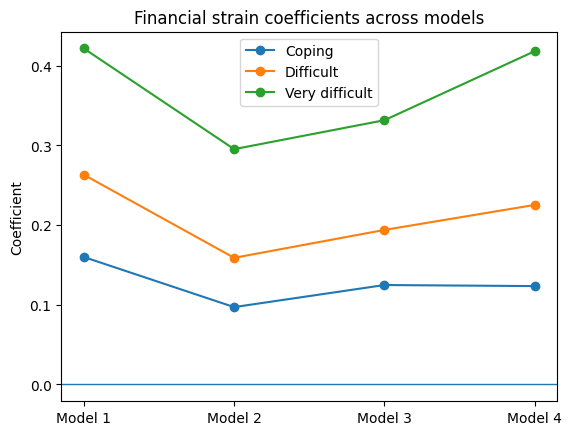

In [ ]:
# Plot the hincfel coefficients across the four model specifications.

models = [1, 2, 3, 4]

plt.plot(
    models,
    [model_1.params["C(hincfel)[T.2.0]"],
     model_2.params["C(hincfel)[T.2.0]"],
     model_3.params["C(hincfel)[T.2.0]"],
     model_4.params["C(hincfel)[T.2.0]"]],
    marker="o",
    label="Coping"
)

plt.plot(
    models,
    [model_1.params["C(hincfel)[T.3.0]"],
     model_2.params["C(hincfel)[T.3.0]"],
     model_3.params["C(hincfel)[T.3.0]"],
     model_4.params["C(hincfel)[T.3.0]"]],
    marker="o",
    label="Difficult"
)

plt.plot(
    models,
    [model_1.params["C(hincfel)[T.4.0]"],
     model_2.params["C(hincfel)[T.4.0]"],
     model_3.params["C(hincfel)[T.4.0]"],
     model_4.params["C(hincfel)[T.4.0]"]],
    marker="o",
    label="Very difficult"
)

plt.axhline(0, linewidth=1)
plt.xticks(models, ["Model 1", "Model 2", "Model 3", "Model 4"])
plt.ylabel("Coefficient")
plt.title("Financial strain coefficients across models")
plt.legend()
plt.show()


Great, that looks good! Now looking at the four models, we can see that the overall pattern for `hincfel` looks quite consistant: Greater financial strain is associated with higher redistribution support in every model specification and the coefficients increase across the three categories.

The largest change happens when household income is added in Model 2, where all three coefficients become noticeably smaller. Adding the additional socioeconomic controls in Model 3 changes relatively little, while the coefficients become somewhat larger again in the final model with political orientation.

When we look at statistical significance, we can see that all three `hincfel` coefficients are statistically significant at the 1% level in Model 1, while in Model 2 none of them remain statistically significant. In Model 3, `Coping` and `Difficult` are significant at the 10% level, while in Model 4 they are significant at the 5% level and `Very difficult` at the 10% level. All in all, while the positive ordering of the coefficients is quite consistant across the models, the statistical significance is less consistant across the different model-specifications.

Lastly, we should also keep in mind that the number of observations decreases across the models, mainly because some of the additional variables contain missing values. So, overall, we can say that the models explain only a modest share of the variation in redistribution support, with R² ranging from 0.014 in Model 1 to 0.096 in Model 4

## 7. Conclusion

Now, to conclude our analysis, we can say that our project suggests that greater financial strain is associated with stronger support for redistribution, even when taking household income into account. The relationship weakens once income (in the form of deciles) is added, which points us to a connection to household income. We can also see that the positive ordering across the financial-strain categories remains visible throughout all four model specifications as well as that the estimated differences are not that large, but not negligible, with their statistical significance varying across the different models.

There are indeed some limitations to keep in mind: The analysis is based on cross-sectional data, which means that it only shows associations. Next off, `redist_support` measures a broad general preference for redistribution and does not distinguish between specific forms of redistribution, like taxation, transfers or wealth redistribution. So respondents with the same score may still have different policy preferences. Additionally, we should also keep in mind that the number of observations decreases across the models because some variables, especially household income, contain a relatively large number of missing values. And at last, redist_support is a short ordinal 1–5 scale which we treat as numeric here, so the exact size of the coefficients should not be overinterpreted.